On va essayer d'importer tous les tableaux du site internet

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

from pathlib import Path

In [2]:
%load_ext autoreload
%autoreload 2
import sys, os; sys.path.append(os.path.abspath('..'))

from pathlib import Path
from src.cosmo_lidar.io import (
    read_radiosonde_dat, read_many_radiosonde,
    save_table, load_table
)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from src.cosmo_lidar import (fetch_html, extract_ut_column_dat_links, read_radiosonde_dat, read_many_radiosonde, save_table, load_table)

from src.cosmo_lidar import (
    fetch_html,
    extract_ut_column_dat_links,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    download_some
)

In [4]:
import matplotlib as mpl #pour choisir la taille des graphiques ?
mpl.rcParams['font.size'] = 14          # taille par défaut des labels/texte
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2.5

In [135]:
from src.cosmo_lidar import (
    fetch_html,
    extract_ut_column_dat_links,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    download_some
)
URL = "https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/"



# === RUN ===
html = fetch_html(URL)
links = extract_ut_column_dat_links(html, base_url=URL)

print(f"Trouvé {len(links)} fichiers .dat dans la colonne 'UT Launch Date* & Data'.")
print("Aperçu des 5 premiers liens :")
for r in links[:5]:
    print("-", r["label"], "->", r["url"])

# (optionnel) test de téléchargement de 3 fichiers
paths = download_some(links, "../data/external/radiosonde", n=210)
paths


Trouvé 210 fichiers .dat dans la colonne 'UT Launch Date* & Data'.
Aperçu des 5 premiers liens :
- None -> https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-08/98082115.dat
- None -> https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-08/98083121.dat
- None -> https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-10/98100917.dat
- None -> https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-10/98101003.dat
- None -> https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-10/98101103.dat
✓ https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-08/98082115.dat -> ../data/external/radiosonde/98082115.dat (632770 bytes)
✓ https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-08/98083121.dat -> ../data/external/radiosonde/98083121.dat (756535 bytes)
✓ https://legacy.nrao.edu/alma/site/Chajnantor/instruments/radiosonde/1998-10/98100917.dat -> ../data/extern

([PosixPath('../data/external/radiosonde/98082115.dat'),
  PosixPath('../data/external/radiosonde/98083121.dat'),
  PosixPath('../data/external/radiosonde/98100917.dat'),
  PosixPath('../data/external/radiosonde/98101003.dat'),
  PosixPath('../data/external/radiosonde/98101103.dat'),
  PosixPath('../data/external/radiosonde/98101116.dat'),
  PosixPath('../data/external/radiosonde/98101202.dat'),
  PosixPath('../data/external/radiosonde/98101218.dat'),
  PosixPath('../data/external/radiosonde/98102414.dat'),
  PosixPath('../data/external/radiosonde/98102512.dat'),
  PosixPath('../data/external/radiosonde/98102521.dat'),
  PosixPath('../data/external/radiosonde/98112405.dat'),
  PosixPath('../data/external/radiosonde/98112411.dat'),
  PosixPath('../data/external/radiosonde/98112416.dat'),
  PosixPath('../data/external/radiosonde/98112423.dat'),
  PosixPath('../data/external/radiosonde/98112516.dat'),
  PosixPath('../data/external/radiosonde/98112521.dat'),
  PosixPath('../data/external/r

In [123]:
print(len(paths[0]))

209


In [141]:
from pathlib import Path
import tempfile, os

file_path = Path("../data/external/radiosonde/98101116.dat")
# écriture dans un fichier temporaire puis remplacement atomique
with file_path.open("r", encoding="utf-8", errors="ignore") as fin, \
        tempfile.NamedTemporaryFile("w", delete=False, encoding="utf-8") as fout:
    next(fin, None)  # saute la première ligne
    for line in fin:
        fout.write(line)
os.replace(fout.name, file_path)  # remplace le fichier d'origine



In [14]:
data_dir = Path("../data/external/radiosonde")
paths = sorted(data_dir.glob("*.dat"))

dfs = read_many_radiosonde(
    paths, per_file=True, save_per_file=False,
    drop_last=2, min_geop=5000, max_geop = 20000, geop_step_threshold = -8.0, sort_geop=True, parse_time=True
)
len(dfs), dfs[0].head()


(209,
                     TIME     PMB  TEMP  TDEW     RH  GEOP      AZ     EL  \
 0 0 days 05:12:39.970000  557.20 -1.37 -4.33  80.15  5035  129.77  28.10   
 1 0 days 05:12:41.070000  557.04 -1.37 -4.34  80.09  5037  129.63  29.30   
 2 0 days 05:12:42.160000  556.82 -1.37 -4.35  80.02  5040  129.88  29.52   
 3 0 days 05:12:43.210000  556.59 -1.32 -4.31  79.93  5043  127.97  29.45   
 4 0 days 05:12:44.310000  556.33 -1.31 -4.33  79.79  5047  128.52  29.65   
 
    SPEED  DIR  E.TIME  RT  Battery __source_file __source_dir __encoding  
 0  999.0  999   10.45   0     7.87  00041305.dat   radiosonde    latin-1  
 1    2.9  301   11.53   0     7.87  00041305.dat   radiosonde    latin-1  
 2    2.9  301   12.60   0     7.85  00041305.dat   radiosonde    latin-1  
 3    3.0  301   13.67   0     7.86  00041305.dat   radiosonde    latin-1  
 4    3.0  301   14.75   0     7.86  00041305.dat   radiosonde    latin-1  )

In [15]:
from pathlib import Path
import pandas as pd
proc = Path("../data/processed"); proc.mkdir(parents=True, exist_ok=True)

skipped = []     # (index, raison)
saved = 0

for i, df in enumerate(dfs):
    # 1) Vérifs de base
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        skipped.append((i, "DataFrame vide"))
        continue
    if "__source_file" not in df.columns:
        skipped.append((i, "colonne __source_file absente"))
        continue
    if len(df["__source_file"]) == 0:
        skipped.append((i, "colonne __source_file vide"))
        continue

    # 2) Nom de sortie sûr
    try:
        src = str(df["__source_file"].iloc[0])
    except IndexError:
        skipped.append((i, "iloc[0] impossible (pas de lignes)"))
        continue

    # Nettoyage / normalisation du nom
    src_name = Path(src).name  # garde juste le nom de fichier
    out_name = src_name.replace(".dat", "_geop5000.parquet")
    out_path = proc / out_name

    # 3) Sauvegarde
    try:
        save_table(df, out_path, fmt="parquet")
        saved += 1
    except Exception as e:
        skipped.append((i, f"échec to_parquet: {e}"))
        continue

print(f"Sauvegardes OK : {saved}")
if skipped:
    print(f"Skipped : {len(skipped)}")
    for idx, reason in skipped[:10]:  # aperçu
        print(f"- df #{idx} -> {reason}")

"""for df in dfs:
    name = df["__source_file"].iloc[0].replace(".dat", "_geop5000.parquet")
    save_table(df, proc / name, fmt="parquet")"""

Sauvegardes OK : 208
Skipped : 1
- df #110 -> DataFrame vide


'for df in dfs:\n    name = df["__source_file"].iloc[0].replace(".dat", "_geop5000.parquet")\n    save_table(df, proc / name, fmt="parquet")'

In [17]:
d = Path("../data/processed")
n = sum(1 for p in d.iterdir() if p.is_file())
print(n)

209


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.cosmo_lidar.atm_tools import calcul_z_percentile_wvc, vapor_pressure, calcul_PWV
from src.cosmo_lidar.mc_tools import predict_SNR_T
from pathlib import Path
import tempfile, os

In [6]:
from src.cosmo_lidar.io import load_parquet_columns_as_numpy, to_float64

# Répertoire contenant les .parquet


PROJECT_ROOT = Path("..").resolve()                     # <- remonte d'un cran
PARQUET_DIR  = PROJECT_ROOT / "data" / "processed"      # data/processed



# Sentinelles typiques pour radiosonde (adaptez si besoin)
SENTINELS = {"AZ":[9999], "EL":[9999], "SPEED":[999], "DIR":[999], "RT":[99.99]}

data = load_parquet_columns_as_numpy(
    root=PARQUET_DIR,
    glob_pattern="*.parquet",          # changez en "**/*.parquet" pour récursif
    exclude_prefixes=("__source_", "__encoding"),
    sentinels=SENTINELS,
    )

print(data)
print(PARQUET_DIR)

# Exemple d’utilisation : lister les colonnes et tailles pour chaque fichier
for p, cols in data.items():
    print(f"\n{p.name}")
    for c, arr in cols.items():
        print(f"  - {c}: shape={arr.shape}, dtype={arr.dtype}")


{PosixPath('/Users/vl284796/Documents/Cosmo-Lidar-Project/Cosmo-lidar-project/data/processed/00041305_geop5000.parquet'): {'TIME': array([18759970000000, 18761070000000, 18762160000000, 18763210000000,
       18764310000000, 18765350000000, 18766450000000, 18767490000000,
       18768590000000, 18769630000000, 18770730000000, 18771780000000,
       18772870000000, 18773920000000, 18775020000000, 18776120000000,
       18777160000000, 18778260000000, 18779300000000, 18780400000000,
       18781440000000, 18782540000000, 18783590000000, 18784680000000,
       18785730000000, 18786830000000, 18787870000000, 18788970000000,
       18790010000000, 18791110000000, 18792150000000, 18793250000000,
       18794300000000, 18795390000000, 18796440000000, 18797540000000,
       18798580000000, 18799680000000, 18800780000000, 18801820000000,
       18802920000000, 18803960000000, 18805010000000, 18806100000000,
       18807200000000, 18808250000000, 18809350000000, 18810390000000,
       1881149000

In [8]:
first_path = sorted(data.keys())[3]
first_cols = data[first_path]

print(first_path)



/Users/vl284796/Documents/Cosmo-Lidar-Project/Cosmo-lidar-project/data/processed/00060716_geop5000.parquet


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.cosmo_lidar.atm_tools import calcul_z_percentile_wvc, vapor_pressure, calcul_PWV
from src.cosmo_lidar.mc_tools import predict_SNR_T

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from src.cosmo_lidar.atm_tools import calcul_z_percentile_wvc, vapor_pressure, calcul_PWV

temp = to_float64(first_cols["TEMP"]) + 273.15 #en K
alt = to_float64(first_cols["GEOP"]) #en m
rh   = to_float64(first_cols["RH"]) #%
T_DEW = to_float64(first_cols["TDEW"]) +273.15 # en K
P_data =  to_float64(first_cols["PMB"]) #en hPa

print(temp.shape)



NameError: name 'first_cols' is not defined

In [11]:
R_water = 461.5 #J/kg/K
epsilon    = 0.622 # rapport des masses molaires de l'eau et de l'air sec


e_1= vapor_pressure(T_DEW) #hPa

rho_water = e_1*100/(R_water*temp) #en kg/m3
wvmr = epsilon * e_1 / (P_data - e_1) *1000 #en g/kg
print(wvmr.shape, alt.shape, P_data.shape, temp.shape)

print(wvmr)

(3793,) (3793,) (3793,) (3793,)
[1.50748623 1.4951828  1.48887828 ... 0.00216574 0.00217726 0.0021699 ]


In [12]:
from src.cosmo_lidar.atm_tools import calcul_PWV

PWV = calcul_PWV(rho_water, alt)
percentile = 50 #%
calcul_percentile_wvc_value = calcul_z_percentile_wvc(alt, rho_water, percentile)

print (calcul_percentile_wvc_value, PWV)

5266.839833232027 0.5445535266039918


In [13]:
pi=np.pi

frequency = np.array([150.e9]) #en Hz
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600)) #en rad
elev = 90 #en
N_MC = 100

# Grille de réduction (altitude)
N_Z       = 200         # nb de points de la grille z réduite
Z_FLOOR   = 5000         # m, éviter 0 pour geomspace

R_water    = 461.5      # J/kg/K
percentile = 50         # %
epsilon    = 0.622      # rapport des masses molaires pour WVMR

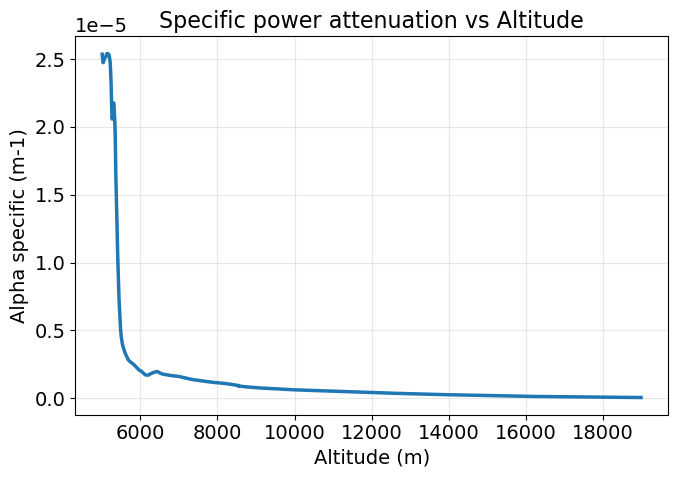

In [14]:
#test sur specific power attenuation

from src.cosmo_lidar.atm_tools import alpha_specific_function

alpha = alpha_specific_function(alt, frequency, temp, P_data, e_1)

plt.figure(figsize=(7,5))
plt.plot(alt, alpha)
plt.xlabel("Altitude (m)")
plt.ylabel("Alpha specific (m-1)")
plt.title("Specific power attenuation vs Altitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
sigma_T, T_ant = predict_SNR_T(
            frequency=frequency,
            theta_b=theta_b,
            z=alt,
            WVMR=wvmr,
            elev=elev,
            T=temp,
            P=P_data,
            N_MC=N_MC
        )

print(T_ant, sigma_T)

[4.47944413] 0.002368125311638284


In [12]:
import numpy as np

def hybrid_lin_geom(zmin, zbreak, zmax, N_lin=80, N_geom=70, gamma=1.0):
    z1 = np.linspace(zmin, zbreak, N_lin, endpoint=False)
    # partie géométrique au-dessus du breakpoint
    t = np.linspace(0, 1, N_geom)
    z2 = zbreak * (zmax / zbreak)**(t**gamma)
    return np.concatenate([z1, z2])

N_lin = 4*N_Z//5
N_geom = N_Z - N_lin
gamma = 2
z_break = calcul_z_percentile_wvc(alt, rho_water, 90)
print(z_break)





NameError: name 'alt' is not defined

On adapte le SNR en fonction du beaming 

In [16]:
from src.cosmo_lidar.atm_tools import mass_quantile_grid


# -- Réduction sur une grille géométrique en z --
zmin = max(float(np.nanmin(alt)), Z_FLOOR)
zmax = float(np.nanmax(alt))

#zg = mass_quantile_grid(alt,rho_water,N_Z)
zg = hybrid_lin_geom(zmin, z_break, zmax, N_lin=N_lin, N_geom=N_geom, gamma=gamma)
#zg = np.linspace(zmin,zmax, N_Z)

# Interpolation linéaire des champs sur zg

T_g  = np.interp(zg, alt, temp)

P_g = np.interp(zg, alt, P_data)
WVMR_g = np.interp(zg, alt, wvmr)





REGLER LE PROBLEME DU SNR

In [18]:
sigma_T_g, T_ant_g = predict_SNR_T(
            frequency=frequency,
            theta_b=theta_b,
            z=zg,
            WVMR=WVMR_g,
            elev=elev,
            T=T_g,
            P=P_g,
            N_MC=N_MC
        )

print(sigma_T_g, T_ant_g)


0.0032449031583905784 [4.50916022]


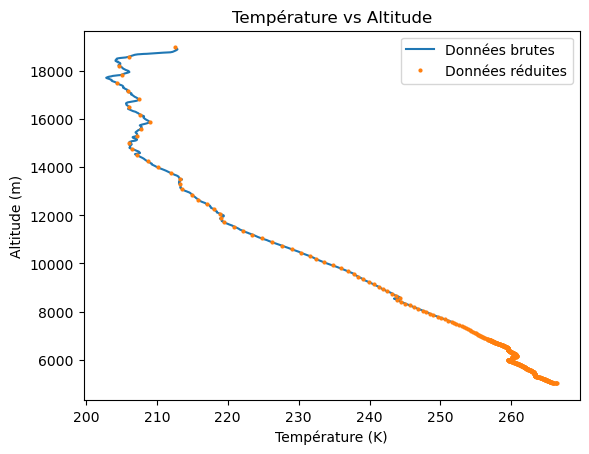

In [39]:
plt.plot(temp,alt, label ="Données brutes")
plt.plot(T_g,zg,'o', label ="Données réduites", markersize=2)
plt.legend()
plt.xlabel("Température (K)")
plt.ylabel("Altitude (m)")
plt.title("Température vs Altitude")
plt.show()

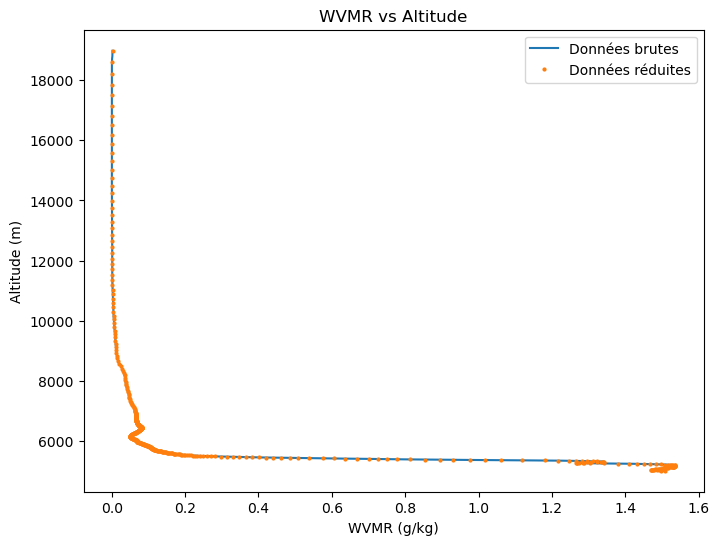

In [40]:
plt.figure(figsize=(8,6))
plt.plot(wvmr,alt, label ="Données brutes")
plt.plot(WVMR_g,zg,'o' ,label ="Données réduites", markersize=2)
plt.legend()
plt.xlabel("WVMR (g/kg)")
plt.ylabel("Altitude (m)")
plt.title("WVMR vs Altitude")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.cosmo_lidar.atm_tools import calcul_z_percentile_wvc, vapor_pressure, calcul_PWV

# paramètres
R_water    = 461.5  # J/kg/K
percentile = 50     # % pour z au percentile
use_geom_first = True  # True si certains fichiers ont "GEOM" au lieu de "GEOP"

per_file_data = {}   # {Path -> dict de séries numpy converties}
summary_rows  = []   # [(filename, PWV, z_percentile, n_used)]



for path in sorted(data.keys()):
    cols = data[path]
    
    

    # Colonnes (avec conversions)
    TEMP = to_float64(cols["TEMP"]) + 273.15 #en K
    Z = to_float64(cols["GEOP"]) #en m
    TDEW = to_float64(cols["TDEW"]) + 273.15 # en K
    RH   = to_float64(cols.get("RH")) if "RH" in cols else None    #en %
    PMB  = to_float64(cols.get("PMB")) if "PMB" in cols else None # en hPa

    # Pression de vapeur à partir de T_dew (en hPa) -> rho_v (kg/m^3)
    e_hPa     = vapor_pressure(TDEW)      # hPa
    rho_water = (e_hPa * 100.0) / (R_water * TEMP)  # Pa / (J/kg/K * K) = kg/m^3
    

    # Masque de points valides pour l’intégration
    m = np.isfinite(Z) & np.isfinite(rho_water)
    z  = Z[m]
    rv = rho_water[m]

    # Défense : il faut au moins 2 points valides
    if z.size < 2 or np.nanmax(z) == np.nanmin(z):
        summary_rows.append((path.name, np.nan, np.nan, int(z.size)))
        continue

    # IMPORTANT : ordonner par altitude croissante (si ce n’est pas déjà le cas)
    order = np.argsort(z)
    z  = z[order]
    rv = rv[order]

    # Calculs demandés
    PWV = calcul_PWV(rv, z)  # kg/m^2 (si ta fonction intègre rv sur z)
    z_p = calcul_z_percentile_wvc(z, rv, percentile)

    # Stockage des séries (brutes converties) si tu veux y revenir
    per_file_data[path] = dict(
        TEMP=TEMP, Z=Z, TDEW=TDEW, RH=RH, PMB=PMB, rho_water=rho_water
    )

    summary_rows.append((path.name, PWV, z_p, int(z.size)))

# Tableau récapitulatif
df_summary = pd.DataFrame(summary_rows, columns=["file", "PWV_kg/m^2", f"z_at_{percentile}pct_m", "N_used"])
display(df_summary)

# Accès exemple :
# df_summary.loc[0, "PWV_kg/m^2"], df_summary.loc[0, f"z_at_{percentile}pct_m"]
# per_file_data[sorted(data.keys())[0]]["rho_water"]


,file,PWV_kg/m^2,z_at_50pct_m,N_used
0,00041305_geop5000.parquet,1.251467,5229.886181,152
1,00060114_geop5000.parquet,27.990317,12459.457522,905
2,00060515_geop5000.parquet,2.634670,6103.921931,597
3,00060716_geop5000.parquet,0.546140,5267.712760,4255
4,00060814_geop5000.parquet,0.196097,6190.293776,4109
...,...,...,...,...
203,99111009_geop5000.parquet,0.569070,5334.510961,2968
204,99111012_geop5000.parquet,0.270000,5717.965156,3718
205,99111018_geop5000.parquet,0.928218,6006.200199,3449
206,99111113_geop5000.parquet,0.411771,5325.249200,2933


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.cosmo_lidar.atm_tools import calcul_z_percentile_wvc, vapor_pressure, calcul_PWV
from src.cosmo_lidar.mc_tools import predict_SNR_T

percentile = 50         # %

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import trapezoid

pi=np.pi
# ---- Paramètres de l’instrument / calcul ----

frequency = np.array([150.e9])
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elev = 45
N_MC = 500

# Grille de réduction (altitude)
N_Z       = 200         # nb de points de la grille z réduite
N_lin     = 4*N_Z//5
N_geom    = N_Z - N_lin
gamma     = 2
Z_FLOOR   = 5000         # m, éviter 0 pour geomspace

R_water    = 461.5      # J/kg/K
percentile = 50         # %
epsilon    = 0.622      # rapport des masses molaires pour WVMR

per_file_data = {}
summary_rows  = []

for path in sorted(data.keys()):
    cols = data[path]

    # Colonnes (avec conversions)
    TEMP = to_float64(cols["TEMP"]) + 273.15         # K
    Z    = to_float64(cols.get("GEOM", cols.get("GEOP")))  # m
    TDEW = to_float64(cols["TDEW"]) + 273.15         # K
    PMB  = to_float64(cols.get("PMB"))               # hPa

    # Pression de vapeur à partir de T_dew (hPa) -> rho_v (kg/m^3)
    e_hPa     = vapor_pressure(TDEW)                 # hPa
    rho_water = (e_hPa * 100.0) / (R_water * TEMP)   # kg/m^3
    
    WVMR = epsilon * e_hPa / (PMB - e_hPa) *1000 #en g/kg


    # Masque de points valides (z, rho_water, TEMP, P)
    m = np.isfinite(Z) & np.isfinite(rho_water) & np.isfinite(TEMP)
    if PMB is not None:
        m &= np.isfinite(PMB)

    z  = Z[m]
    rv = rho_water[m]
    T  = TEMP[m]
    P  = PMB[m] if PMB is not None else None
    w  = WVMR[m]

    if z.size < 2 or (np.nanmax(z) == np.nanmin(z)):
        summary_rows.append((path.name, np.nan, np.nan, np.nan, np.nan, int(z.size)))
        continue

    # -- Réduction sur une grille géométrique en z --
    zmin = max(float(np.nanmin(z)), Z_FLOOR)
    zmax = float(np.nanmax(z))
    if zmax <= zmin:
        summary_rows.append((path.name, np.nan, np.nan, np.nan, np.nan, int(z.size)))
        continue

    z_break = calcul_z_percentile_wvc(z, rv, 90)
    zg = hybrid_lin_geom(zmin, z_break, zmax, N_lin=N_lin, N_geom=N_geom, gamma=gamma)

    # Interpolation linéaire des champs sur zg
    rv_g = np.interp(zg, z, rv)
    T_g  = np.interp(zg, z, T)
    P_g = np.interp(zg, z, P)
    WVMR_g = np.interp(zg, z, w)
    

    # ---- Calculs demandés ----
    # PWV (intégrale rho_v dz) — 
    
    PWV = calcul_PWV(rv, z)   

    # z au percentile
    z_p = calcul_z_percentile_wvc(z, rv, percentile)
    
    # calcul de z_moy et std_vert
    Mcol = calcul_PWV(rv, z)  # kg/m^2
    z_moy = trapezoid(rv * z, z) / Mcol
    var_vert = trapezoid(rv * (z - z_moy)**2, z) / Mcol
    std_vert = np.sqrt(var_vert)

    # Antenna temperature & sigma_T (sur profil réduit)
    try:
        sigma_T, T_ant = predict_SNR_T(
            frequency=frequency,
            theta_b=theta_b,
            z=zg,
            WVMR=WVMR_g,
            elev=elev,
            T=T_g,
            P=P_g,
            N_MC=N_MC
        )
    except Exception as err:
        # On n’interrompt pas la boucle si un fichier pose souci
        T_ant, sigma_T = np.nan, np.nan
        print(f"[WARN] {path.name}: predict_SNR_T a échoué -> {err}")

    # Stockage
    per_file_data[path] = dict(
        Z=z, TEMP=T, rho_water=rv, P=P, WVMR=w,
        z_grid=zg, TEMP_grid=T_g, P_grid=P_g, WVMR_grid=WVMR_g
    )

    summary_rows.append((path.name, PWV, z_moy, std_vert, z_p, T_ant[0], sigma_T, int(z.size)))

# Tableau récapitulatif étendu
df_summary = pd.DataFrame(
    summary_rows,
    columns=["file", "PWV_kg/m^2", "z_moyen","std_vertical", f"z_at_{percentile}pct_m", "T_antenna", "sigma_T", "N_used"]
)
display(df_summary)


In [ ]:
from pathlib import Path

# 1) Retrouver la racine projet (ou adapte si tu sais déjà où tu es)
PROJECT_ROOT = Path("..").resolve()   # si ton notebook est dans Cosmo-lidar-project/notebooks
# PROJECT_ROOT = Path(".").resolve()  # si tu exécutes depuis la racine du projet

# 2) Construire le chemin de sortie dans data/processed
out_parquet = PROJECT_ROOT / "data" / "raw" / f"summary_zp_Tant_{percentile}_november2_45_deg.parquet"
out_csv     = PROJECT_ROOT / "data" / "raw" / f"summary_zp_Tant_{percentile}_november2_45_degcsv"

# 3) Sauvegarder (choisis le format que tu veux)
save_table(df_summary, out_parquet, fmt="parquet")
save_table(df_summary, out_csv, fmt="csv")  # option CSV en plus si tu veux

print("Sauvegardé :", out_parquet, "| Existe ? ", out_parquet.exists())
# print("Sauvegardé :", out_csv, "| Existe ? ", out_csv.exists())


Sauvegardé : /Users/vl284796/Documents/Cosmo-Lidar-Project/Cosmo-lidar-project/data/raw/summary_zp_Tant_50_november2.parquet | Existe ?  True


In [ ]:
from pathlib import Path

# 1) Retrouver la racine projet (ou adapte si tu sais déjà où tu es)
PROJECT_ROOT = Path("..").resolve()   # si ton notebook est dans Cosmo-lidar-project/notebooks
# PROJECT_ROOT = Path(".").resolve()  # si tu exécutes depuis la racine du projet

# 2) Construire le chemin de sortie dans data/processed
out_parquet = PROJECT_ROOT / "data" / "raw" / f"summary_zp_Tant_{percentile}_november2.parquet"
df_summary = load_table(out_parquet)

on voudrait calculer pour chaque tableau le terme : l'intégrale entre sur l'altitude de (z-z0)^2 * wvmr

In [94]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from src.cosmo_lidar.atm_tools import vapor_pressure, pwv_profile
from src.cosmo_lidar.io import to_float64

# Constantes physiques
R_water = 461.5    # J/(kg·K)
epsilon = 0.622    # rapport des masses molaires Mv/Md

PROJECT_ROOT = Path("..").resolve()                     # <- remonte d'un cran
PARQUET_DIR  = PROJECT_ROOT / "data" / "processed-graph"  # ../data/processed-graph
PARQUET_DIR.mkdir(parents=True, exist_ok=True)


exclude_files_e = [
    "00070316_geop5000.parquet",
    "01050123_geop5000.parquet",
    "00062715_geop5000.parquet",
    "98120822_geop5000.parquet",
    "01042614_geop5000.parquet",
    "01120919_geop5000.parquet",
    "00060114_geop5000.parquet",
    "00073117_geop5000.parquet",
]

# Dictionnaire où l'on va stocker le moment pour chaque path
moments_water = {}

for path in sorted(data.keys()):
    
    if path.name in exclude_files_e:
        continue  # on saute ce fichier

    
    cols = data[path]

    # ---------------------------
    # Colonnes physiques
    # ---------------------------
    TEMP = to_float64(cols["TEMP"]) + 273.15        # K
    Z    = to_float64(cols["GEOP"])                 # m ; déjà trié croissant (bas -> haut)
    TDEW = to_float64(cols["TDEW"]) + 273.15        # K

    RH   = to_float64(cols.get("RH"))  if "RH"  in cols else None   # %
    PMB  = to_float64(cols.get("PMB")) if "PMB" in cols else None   # hPa

    # ---------------------------
    # Vapeur d'eau
    # ---------------------------
    # Pression partielle de vapeur (hPa) à partir du point de rosée
    e_hPa = vapor_pressure(TDEW)  # ta fonction existante

    # Densité de vapeur d'eau rho_water (kg/m^3)
    rho_water = (e_hPa * 100.0) / (R_water * TEMP)

    # Rapport de mélange vapeur d'eau : WVMR (g/kg)
    # epsilon * e / (P - e) donne kg/kg ; *1000 -> g/kg
    if PMB is not None:
        # WVMR en g/kg
        WVMR = epsilon * e_hPa / (PMB - e_hPa) * 1000.0

        # z0 = Z[0]
        z0 = Z[0]

        # (z - z0)^2 * q(z)
        integrand = rho_water * (Z - z0)**2

        # ton calcul de moment (attention: calcul_PWV doit intégrer par rapport à Z)
        moment_water = calcul_PWV(integrand, Z)

        # on stocke dans le dictionnaire
        moments_water[path] = np.sqrt (moment_water)
    else:
        # si pas de pression, on peut choisir de ne rien mettre ou mettre np.nan
        moments_water[path] = np.nan
        

moments_array = np.array(list(moments_water.values()), dtype=float)  # en g/kg*m3


In [56]:
print(sorted(data.keys())[0].name)

00041305_geop5000.parquet


In [19]:
exclude_files = {"00070316_geop5000.parquet", "01050123_geop5000.parquet", "00062715_geop5000.parquet", "98120822_geop5000.parquet", "01042614_geop5000.parquet","01120919_geop5000.parquet","01120919_geop5000.parquet", "00060114_geop5000.parquet", "00073117_geop5000.parquet"}#, "2024-06-03_B.parquet"}  # noms à exclure

df_filt = df_summary[~df_summary["file"].isin(exclude_files)].copy()

# Récupère les colonnes utiles
pwv_graph = df_filt["PWV_kg/m^2"].to_numpy() #en kg/m2
z_50_graph = df_filt[f"z_at_{percentile}pct_m"].to_numpy() #en m
sigma_T_graph = df_filt["sigma_T"].to_numpy() #en K , 
T_ant_graph = df_filt["T_antenna"].to_numpy()  #en K , 
z_moy_graph = df_filt["z_moyen"].to_numpy() #en m
std_vert_graph = df_filt["std_vertical"].to_numpy() #en m
#T_ant_graph = pd.Series(T_ant_graph).apply(lambda v: np.asarray(v).ravel()[0] if np.asarray(v).size >= 1 else np.nan).to_numpy(dtype=float)
files = df_filt["file"].to_numpy()

# condition "qui gêne" : y < 1500
bad_mask = (z_50_graph > 10000) | (pwv_graph > 10)

# fichiers à signaler
fichiers_genants = files[bad_mask].tolist()
print("Fichiers filtrés (z_p  1500 m) :", fichiers_genants)

# filtre synchronisé pour le tracé (on garde les bons)
good_mask = ~bad_mask & np.isfinite(pwv_graph) & np.isfinite(z_50_graph) #& np.isfinite(sigma_T_graph) & np.isfinite(T_ant_graph)
pwv_graph_plot = pwv_graph[good_mask]
z_50_graph_plot = z_50_graph[good_mask]
sigma_T_graph_plot = sigma_T_graph[good_mask]
T_ant_graph_plot = T_ant_graph[good_mask]
z_moy_graph_plot = z_moy_graph[good_mask]
std_vert_graph_plot = std_vert_graph[good_mask]
sigma_rel_graph_plot = (sigma_T_graph_plot / T_ant_graph_plot) * 100

z_0_graph_plot = np.full(len(pwv_graph_plot), 5000)  # valeur constante de z0 = 5000 m pour tous les profils

#moments_array_plot = moments_array[good_mask]





Fichiers filtrés (z_p  1500 m) : []


In [66]:
print(moments_array_plot.shape, sigma_T_graph_plot.shape)

(199,) (199,)


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/2115738455.py:9: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_T$ (mK)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/2115738455.py:10: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma_T$ vs PWV ")


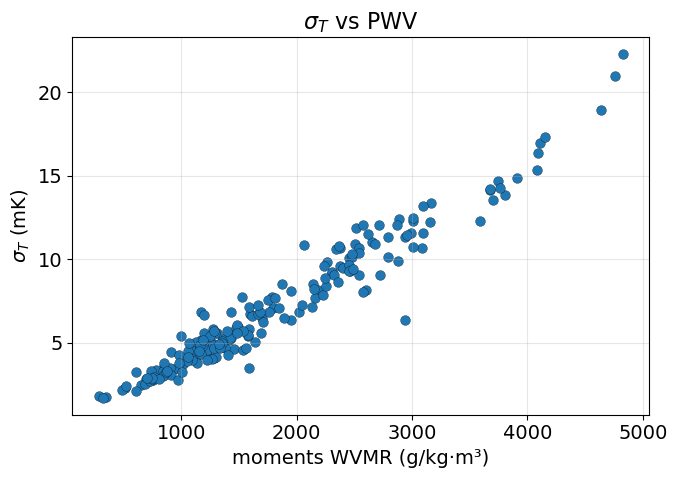

In [96]:
#test avec le moment

fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(moments_array_plot, sigma_T_graph_plot*1000, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("moments WVMR (g/kg·m³)")
ax.set_ylabel(f"$\sigma_T$ (mK)")
ax.set_title(f"$\sigma_T$ vs PWV ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3260683188.py:10: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_T$ (mK)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3260683188.py:12: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma_T$ vs PWV ")


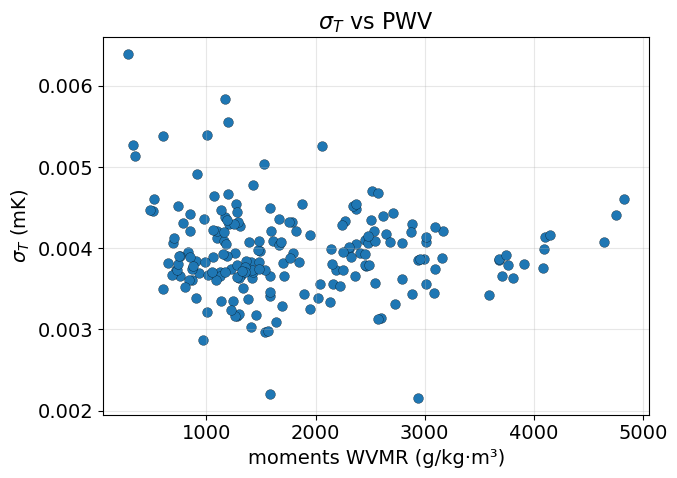

In [97]:
#test avec le moment

fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(moments_array_plot, sigma_T_graph_plot*1000/moments_array_plot, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("moments WVMR (g/kg·m³)")

ax.set_ylabel(f"$\sigma_T$ (mK)")

ax.set_title(f"$\sigma_T$ vs PWV ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

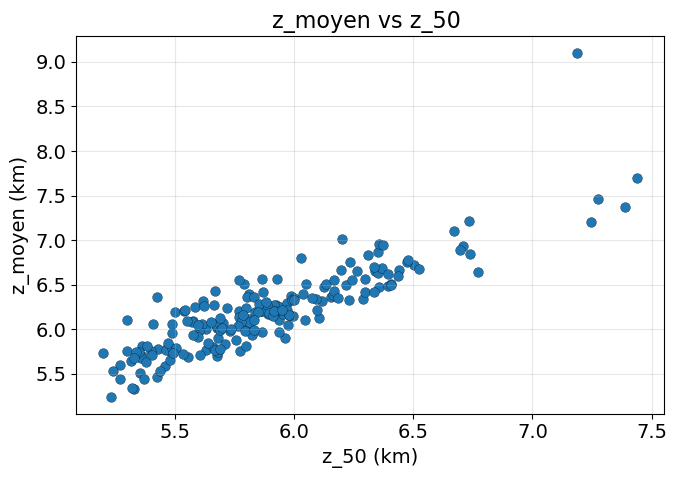

In [17]:
#test avec le moment

fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(z_50_graph_plot/1000, z_moy_graph_plot/1000, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("z_50 (km)")

ax.set_ylabel("z_moyen (km)")

ax.set_title(f"z_moyen vs z_50 ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

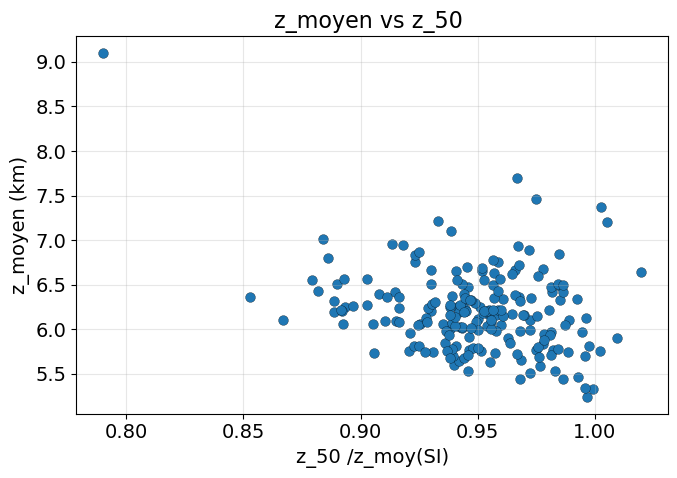

In [18]:
#test avec le moment

fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(z_50_graph_plot/z_moy_graph_plot, z_moy_graph_plot/1000, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("z_50 /z_moy(SI)")

ax.set_ylabel("z_moyen (km)")

ax.set_title(f"z_moyen vs z_50 ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

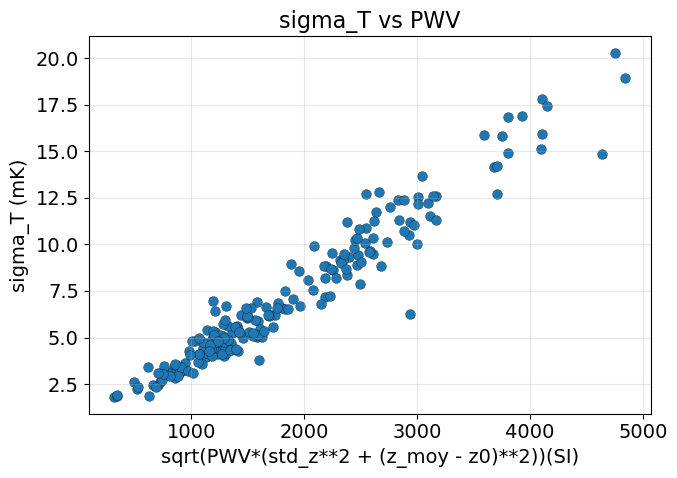

In [30]:


fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(np.sqrt(pwv_graph_plot*(std_vert_graph_plot**2 + (z_moy_graph_plot-z_0_graph_plot)**2)), sigma_T_graph_plot*1000, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("sqrt(PWV*(std_z**2 + (z_moy - z0)**2))(SI)")

ax.set_ylabel("sigma_T (mK)")

ax.set_title("sigma_T vs PWV")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

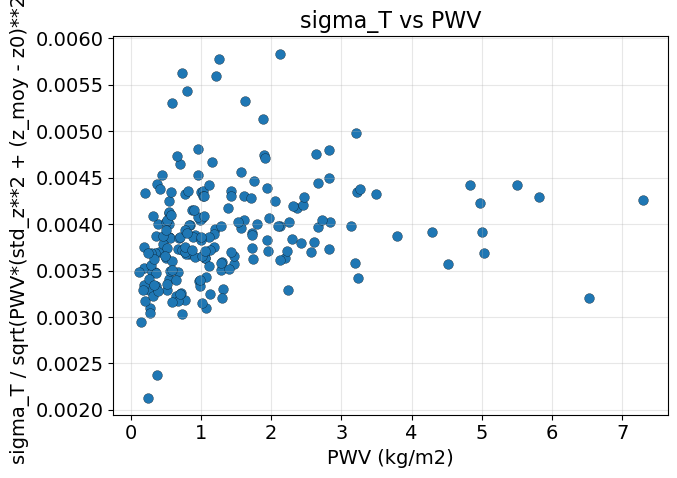

In [31]:


fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, sigma_T_graph_plot*1000/np.sqrt(pwv_graph_plot*(std_vert_graph_plot**2 + (z_moy_graph_plot-z_0_graph_plot)**2)), s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("PWV (kg/m2)")

ax.set_ylabel("sigma_T / sqrt(PWV*(std_z**2 + (z_moy - z0)**2)")
#ax.set_ylim(0,0.5e-5)
ax.set_title("sigma_T vs PWV")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

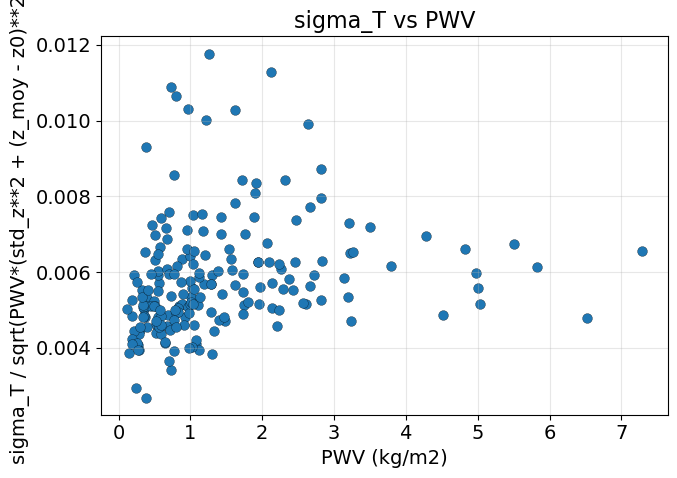

In [ ]:


fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, sigma_T_graph_plot*1000/np.sqrt(pwv_graph_plot*(std_vert_graph_plot**2 
                                                                                #+ (z_moy_graph_plot-z_0_graph_plot)**2)
                                                                                ))
                , s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("PWV (kg/m2)")

ax.set_ylabel("sigma_T / sqrt(PWV*(std_z**2 + (z_moy - z0)**2)")
#ax.set_ylim(0,0.5e-5)
ax.set_title("sigma_T vs PWV")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

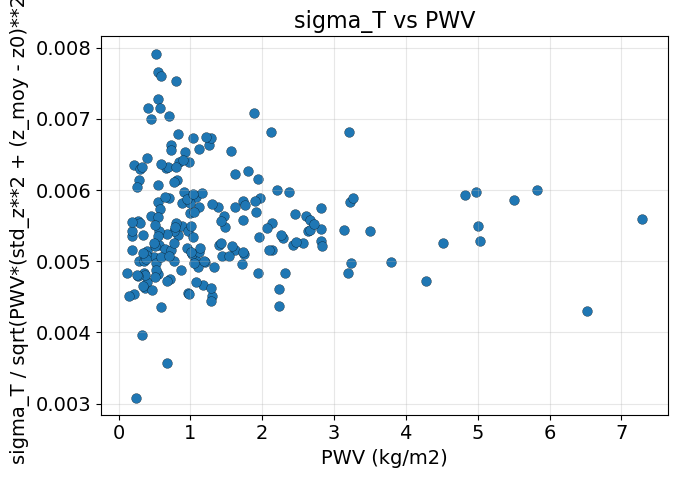

In [34]:


fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, sigma_T_graph_plot*1000/np.sqrt(pwv_graph_plot*( (z_moy_graph_plot-z_0_graph_plot)**2)), s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("PWV (kg/m2)")

ax.set_ylabel("sigma_T / sqrt(PWV*(std_z**2 + (z_moy - z0)**2)")
#ax.set_ylim(0,0.5e-5)
ax.set_title("sigma_T vs PWV")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

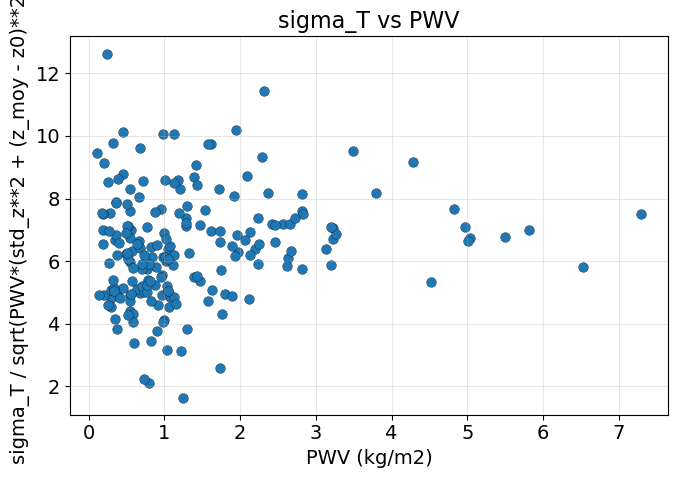

In [35]:


fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, sigma_T_graph_plot*1000/np.sqrt(pwv_graph_plot), s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("PWV (kg/m2)")

ax.set_ylabel("sigma_T / sqrt(PWV*(std_z**2 + (z_moy - z0)**2)")
#ax.set_ylim(0,0.5e-5)
ax.set_title("sigma_T vs PWV")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

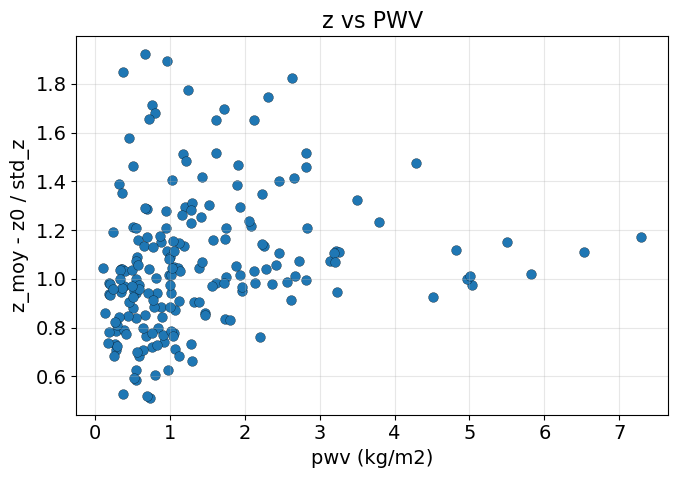

In [27]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot,(z_moy_graph_plot-z_0_graph_plot)/std_vert_graph_plot, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("pwv (kg/m2)")

ax.set_ylabel("z_moy - z0 / std_z")

ax.set_title("z vs PWV")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

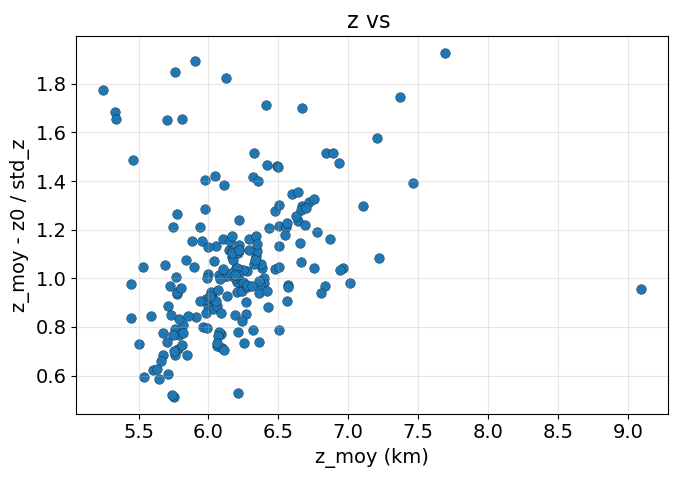

In [28]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(z_moy_graph_plot/1000,(z_moy_graph_plot-z_0_graph_plot)/std_vert_graph_plot, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("z_moy (km)")

ax.set_ylabel("z_moy - z0 / std_z")

ax.set_title("z vs ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

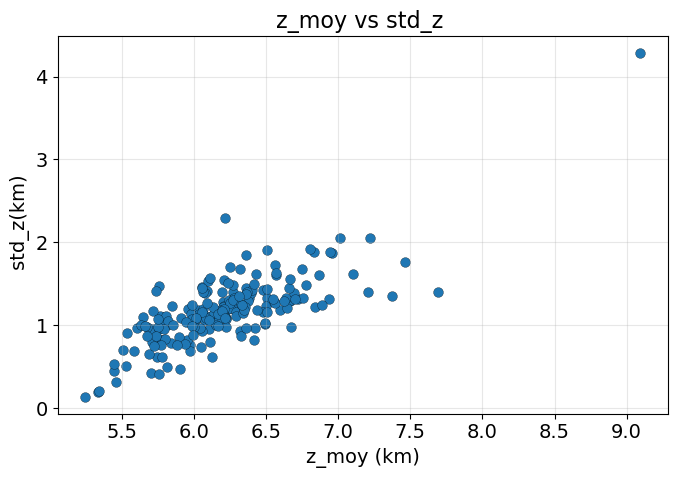

In [38]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(z_moy_graph_plot/1000,std_vert_graph_plot/1000, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("z_moy (km)")

ax.set_ylabel(" std_z(km)")

ax.set_title("z_moy vs std_z ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/2013848918.py:11: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$)")


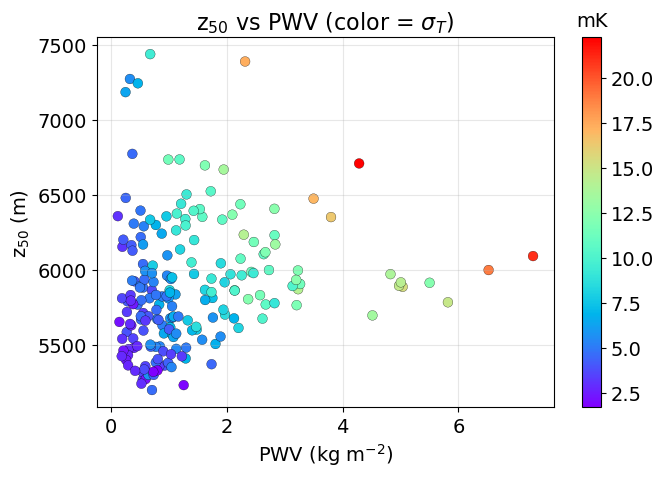

In [25]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_T_graph_plot*1000, cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.set_title('mK', pad=8, fontsize=14) # 'mK' au-dessus de la barre de couleur"
ax.set_label("sigma_T (K)")
#ax.set_xlim(0,1)
ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"z$_{{{percentile}}}$ (m)")
ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

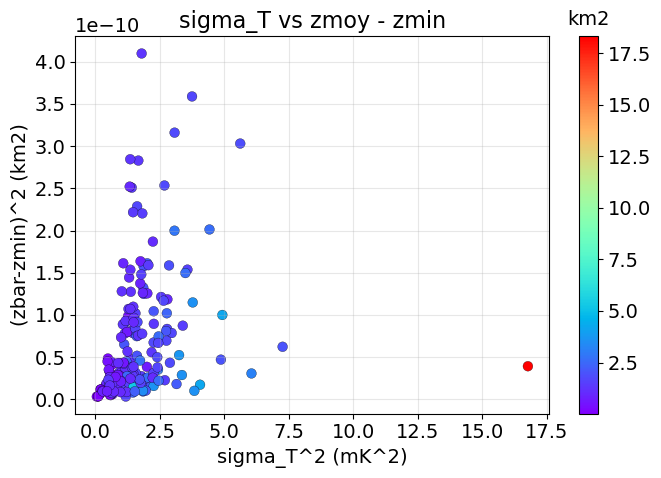

In [40]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter((z_moy_graph_plot/1000-z_0_graph_plot/1000)**2, (sigma_T_graph_plot/1000)**2, c=(std_vert_graph_plot/1000)**2, cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.set_title('km2', pad=8, fontsize=14) # 'mK' au-dessus de la barre de couleur"
ax.set_label("std^2 (km2)")
#ax.set_xlim(0,1)
ax.set_xlabel("sigma_T^2 (mK^2)")
ax.set_ylabel("(zbar-zmin)^2 (km2)")
ax.set_title("sigma_T vs zmoy - zmin")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

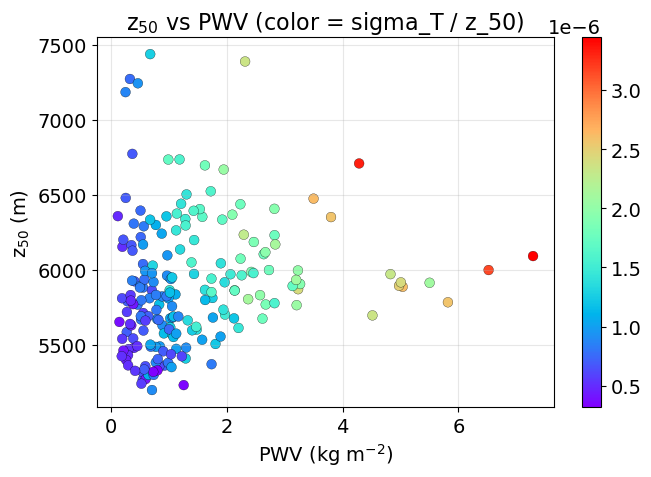

In [99]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_T_graph_plot/z_50_graph_plot, cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
ax.set_label("sigma_T (K)")
#ax.set_xlim(0,1)
ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"z$_{{{percentile}}}$ (m)")
ax.set_title("z$_{50}$ vs PWV (color = sigma_T / z_50)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23060/1784420431.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_T$ (mK)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23060/1784420431.py:8: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma_T$ vs PWV ")


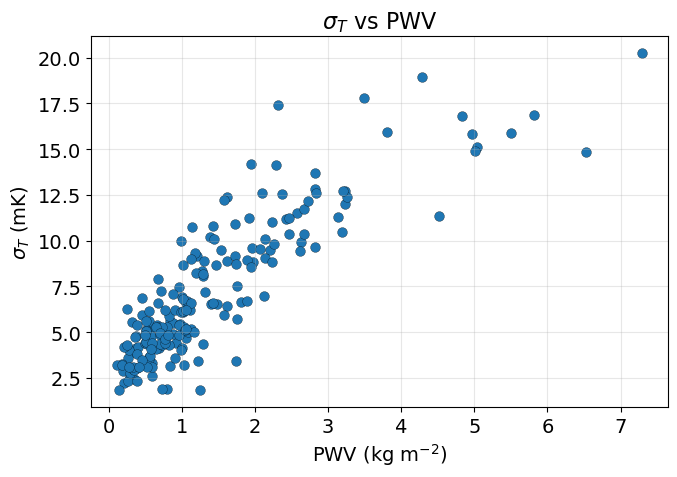

In [29]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, sigma_T_graph_plot*1000, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"$\sigma_T$ (mK)")
ax.set_title(f"$\sigma_T$ vs PWV ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/2034685613.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_T$ (mK)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/2034685613.py:8: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma_T$ vs PWV ")


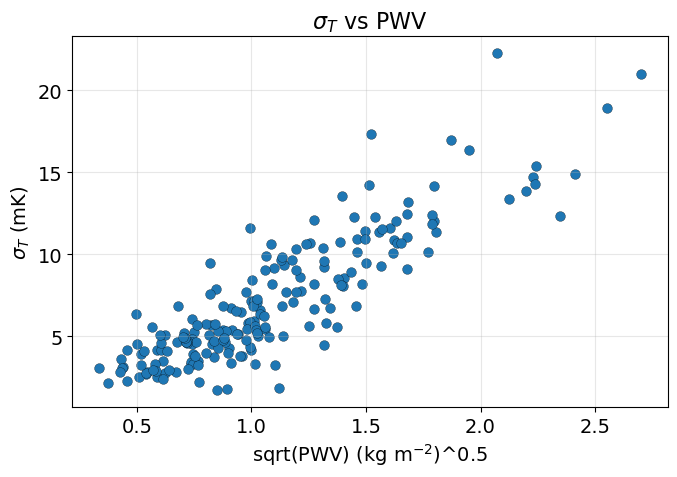

In [44]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(np.sqrt(pwv_graph_plot), sigma_T_graph_plot*1000, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("sqrt(PWV) (kg m$^{-2}$)^0.5")
ax.set_ylabel(f"$\sigma_T$ (mK)")
ax.set_title(f"$\sigma_T$ vs PWV ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3457587691.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_T$ (mK) / sqrt(PWV))")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3457587691.py:8: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma_T$ vs PWV ")


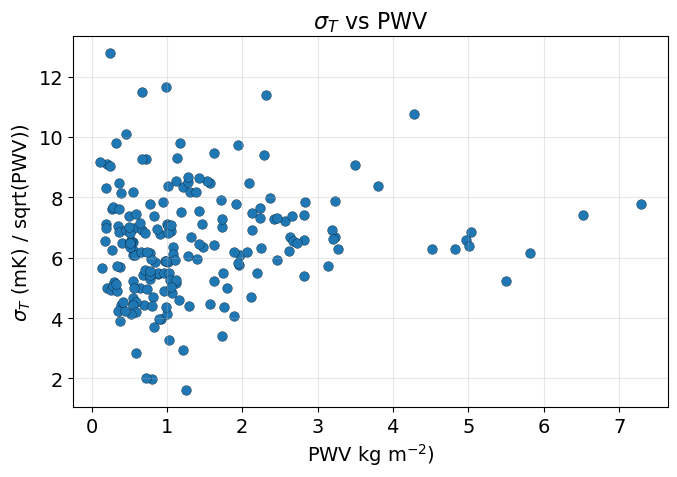

In [45]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, sigma_T_graph_plot*1000/ np.sqrt(pwv_graph_plot), s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("PWV kg m$^{-2}$)")
ax.set_ylabel(f"$\sigma_T$ (mK) / sqrt(PWV))")
ax.set_title(f"$\sigma_T$ vs PWV ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3742290620.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_T$ (mK) /PWV)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3742290620.py:8: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma_T$ vs PWV ")


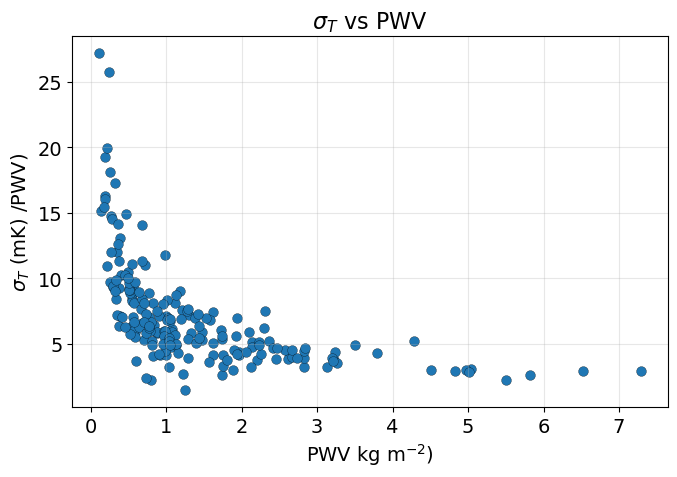

In [46]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, sigma_T_graph_plot*1000/ (pwv_graph_plot), s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("PWV kg m$^{-2}$)")
ax.set_ylabel(f"$\sigma_T$ (mK) /PWV)")
ax.set_title(f"$\sigma_T$ vs PWV ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/5820244.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_T$ / PWV (mK/mm)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/5820244.py:9: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma_T$/PWV vs z_50 ")


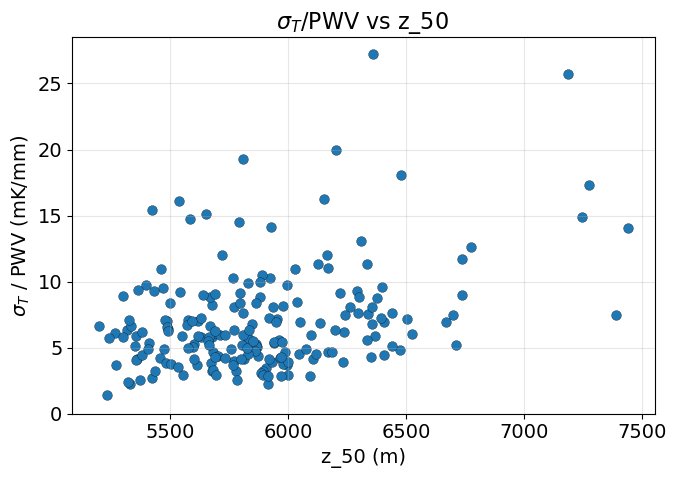

In [28]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(z_50_graph_plot, sigma_T_graph_plot*1000/pwv_graph_plot, s=50, edgecolor="k", linewidth=0.2)

ax.set_xlabel("z_50 (m)")
ax.set_ylabel(f"$\sigma_T$ / PWV (mK/mm)")
ax.set_ylim(bottom=0)
ax.set_title(f"$\sigma_T$/PWV vs z_50 ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3744566062.py:11: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/PWV)")


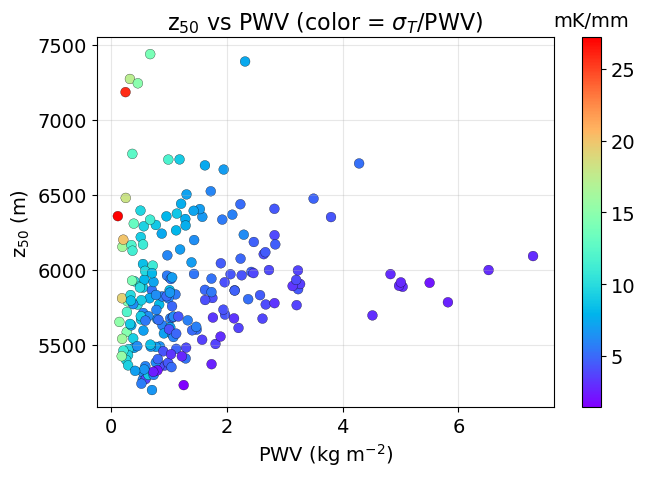

In [29]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_T_graph_plot*1000/pwv_graph_plot, cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.set_title('mK/mm', pad=8, fontsize=14) # 'mK' au-dessus de la barre de couleur"
ax.set_label("sigma_T (K)")
#ax.set_xlim(0,1)
ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"z$_{{{percentile}}}$ (m)")
ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/PWV)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/3610691987.py:11: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/moment WVMR)")


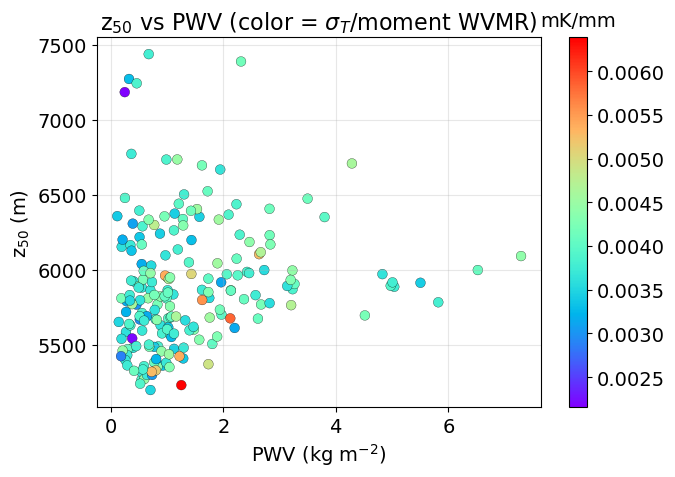

In [107]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_T_graph_plot*1000/moments_array_plot, cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.set_title('mK/mm', pad=8, fontsize=14) # 'mK' au-dessus de la barre de couleur"
ax.set_label("sigma_T (K)")
#ax.set_xlim(0,1)
ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"z$_{{{percentile}}}$ (m)")
ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/moment WVMR)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/2778771776.py:11: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/z$_{50}$)")


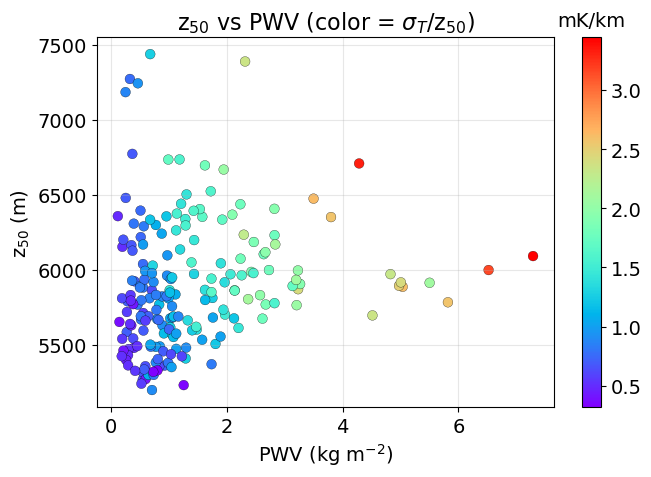

In [102]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_T_graph_plot*1000/(z_50_graph_plot/1000), cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.set_title('mK/km', pad=8, fontsize=14) # 'mK' au-dessus de la barre de couleur"
ax.set_label("sigma_T (K)")
#ax.set_xlim(0,1)
ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"z$_{{{percentile}}}$ (m)")
ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/z$_{50}$)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
"""fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_T_graph_plot*1000/(z_50_graph_plot2*pwv_graph_plot), cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.set_title('mK/m', pad=8, fontsize=14) # 'mK' au-dessus de la barre de couleur"
ax.set_label("sigma_T (K)")
#ax.set_xlim(0,1)
ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"z$_{{{percentile}}}$ (m)")
ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/z$_{50}$)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()"""

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_95809/2288445782.py:11: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$/z$_{50}$)")


'fig, ax = plt.subplots(figsize=(7,5))\n#cond = pwv_graph_plot<1\n#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)\nsc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_T_graph_plot*1000/(z_50_graph_plot2*pwv_graph_plot), cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)\ncbar = fig.colorbar(sc, ax=ax)\ncbar.ax.set_title(\'mK/m\', pad=8, fontsize=14) # \'mK\' au-dessus de la barre de couleur"\nax.set_label("sigma_T (K)")\n#ax.set_xlim(0,1)\nax.set_xlabel("PWV (kg m$^{-2}$)")\nax.set_ylabel(f"z$_{{{percentile}}}$ (m)")\nax.set_title("z$_{50}$ vs PWV (color = $\\sigma_T$/z$_{50}$)")\nax.grid(alpha=0.3)\nplt.tight_layout()\nplt.show()'

In [21]:
print(sigma_T_graph_plot)

[0.00339714 0.02383468 0.0015869  0.00112239 0.0015895  0.00195159
 0.00250613 0.00225889 0.00888775 0.01142518 0.00273016 0.00329061
 0.00386823 0.00390315 0.00448581 0.00287897 0.0035957  0.00121646
 0.001712   0.0073825  0.00290744 0.00949704 0.00145938 0.00251605
 0.00270258 0.00312881 0.01271898 0.00374124 0.00518475 0.00461908
 0.00511328 0.0035561  0.00100794 0.0009822  0.00148687 0.00091262
 0.00212302 0.00313544 0.00268475 0.00172132 0.00566143 0.04020957
 0.00690647 0.00581455 0.00319549 0.00361181 0.00426026 0.00308697
 0.00473574 0.00902642 0.00517573 0.01160869 0.00853007 0.01983894
 0.01381489 0.00580419 0.00375457 0.00351826 0.00764518 0.00740402
 0.01834154 0.01756476 0.02343648 0.00914545 0.0050218  0.01101277
 0.00501955 0.01282177 0.01455476 0.00592748 0.01669381 0.01665534
 0.01849418 0.01172087 0.00805713 0.0029484  0.00647276 0.00261855
 0.00164833 0.00330733 0.00734323 0.01595227 0.01443215 0.01353808
 0.02861577 0.01247803 0.01895193 0.01016819 0.01030907 0.0163

[]

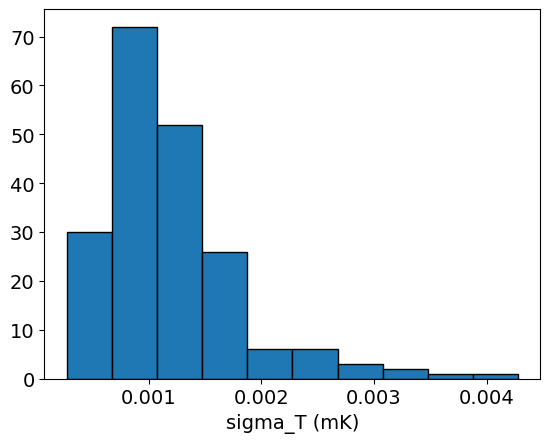

In [32]:
from matplotlib import pyplot as plt
plt.hist(sigma_T_graph_plot*1000/(pwv_graph_plot*z_50_graph_plot), bins=10, edgecolor='black')
plt.xlabel("sigma_T (mK)")

plt.plot()

[]

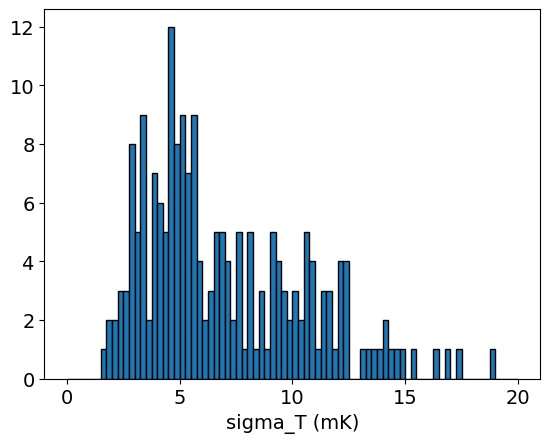

In [33]:
from matplotlib import pyplot as plt
plt.hist(sigma_T_graph_plot*1000, bins=80, range =[0, 20], edgecolor='black')
plt.xlabel("sigma_T (mK)")

plt.plot()

[]

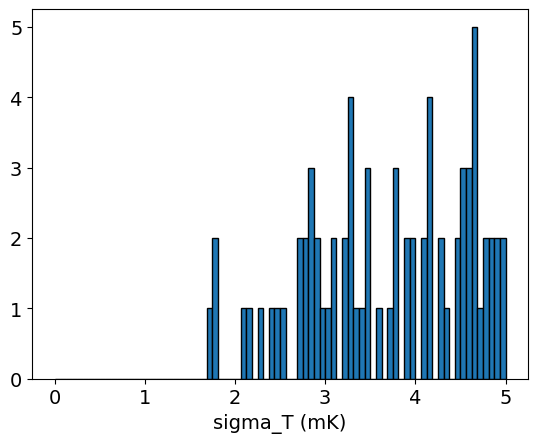

In [41]:
from matplotlib import pyplot as plt
plt.hist(sigma_T_graph_plot*1000, bins=80, range =[0, 5], edgecolor='black')
plt.xlabel("sigma_T (mK)")

plt.plot()

[]

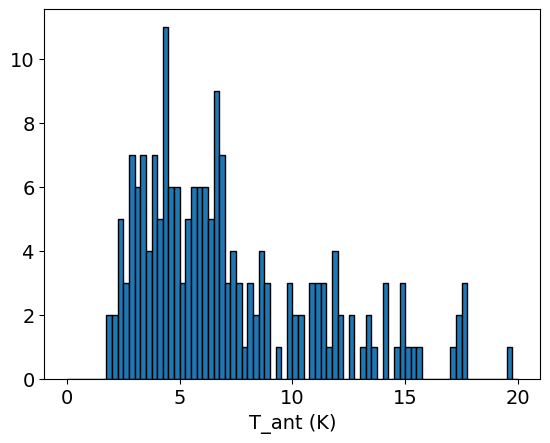

In [34]:

plt.hist(T_ant_graph_plot, bins=80, range =[0, 20], edgecolor='black')
plt.xlabel("T_ant (K)")

plt.plot()

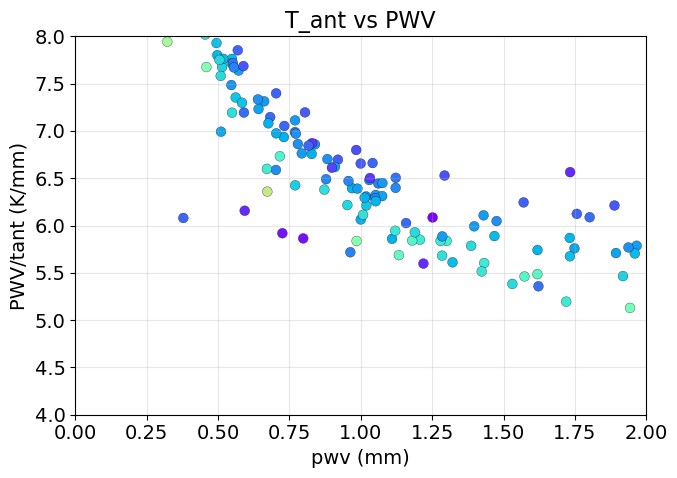

In [43]:
plt.figure(figsize=(7,5))
plt.scatter(pwv_graph_plot,T_ant_graph_plot/pwv_graph_plot, c=z_moy_graph_plot, cmap= 'rainbow', s=50, edgecolor="k", linewidth=0.2)
plt.xlabel("pwv (mm)")
plt.ylabel("PWV/tant (K/mm)")
plt.ylim(4,8)
plt.xlim(0,2)
plt.title("T_ant vs PWV")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

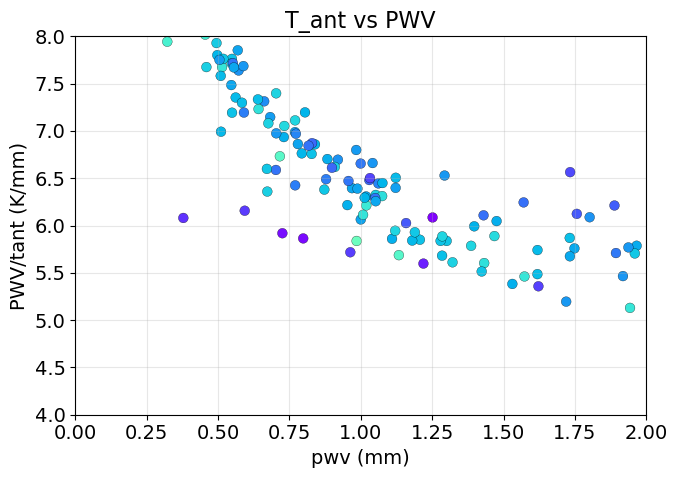

In [44]:
plt.figure(figsize=(7,5))
plt.scatter(pwv_graph_plot,T_ant_graph_plot/pwv_graph_plot, c=std_vert_graph_plot, cmap= 'rainbow', s=50, edgecolor="k", linewidth=0.2)
plt.xlabel("pwv (mm)")
plt.ylabel("PWV/tant (K/mm)")
plt.ylim(4,8)
plt.xlim(0,2)
plt.title("T_ant vs PWV")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

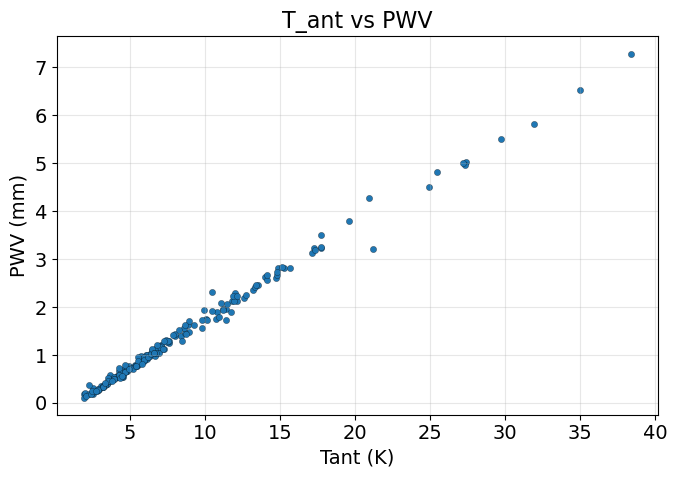

In [104]:
plt.figure(figsize=(7,5))
plt.scatter(T_ant_graph_plot,pwv_graph_plot, s=20, edgecolor="k", linewidth=0.2)
plt.xlabel("Tant (K)")
plt.ylabel("PWV (mm)")
plt.title("T_ant vs PWV")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

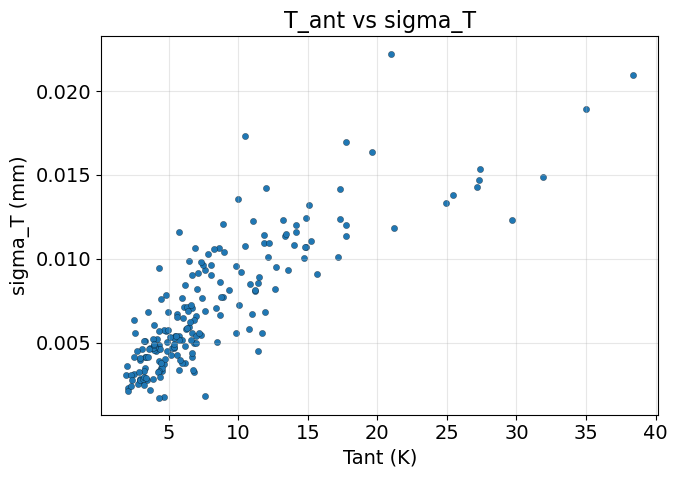

In [38]:
plt.figure(figsize=(7,5))
plt.scatter(T_ant_graph_plot,sigma_T_graph_plot, s=20, edgecolor="k", linewidth=0.2)
plt.xlabel("Tant (K)")
plt.ylabel("sigma_T (mm)")
plt.title("T_ant vs sigma_T")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'


/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_87498/4243612862.py:11: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$relative)")


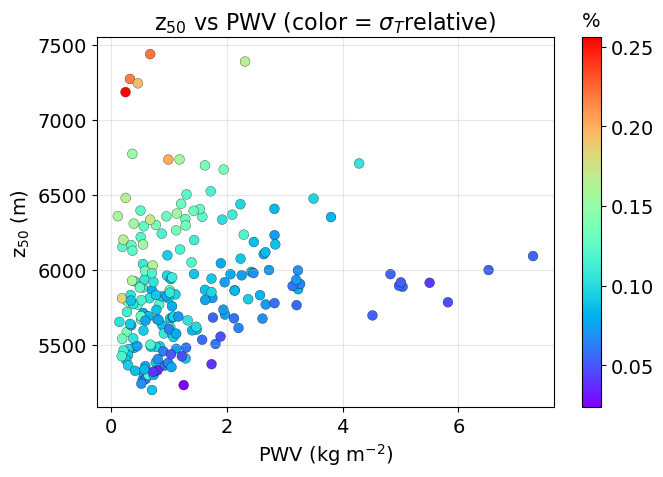

In [103]:
fig, ax = plt.subplots(figsize=(7,5))
#cond = pwv_graph_plot<1
#sc = ax.scatter(pwv_graph_plot[cond], z_50_graph_plot[cond], c=sigma_T_graph_plot[cond], cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
sc = ax.scatter(pwv_graph_plot, z_50_graph_plot, c=sigma_rel_graph_plot, cmap="rainbow", s=50, edgecolor="k", linewidth=0.2)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.set_title('%', pad=8, fontsize=14) # 'mK' au-dessus de la barre de couleur"
ax.set_label("sigma_T (K)")
#ax.set_xlim(0,1)
ax.set_xlabel("PWV (kg m$^{-2}$)")
ax.set_ylabel(f"z$_{{{percentile}}}$ (m)")
ax.set_title("z$_{50}$ vs PWV (color = $\sigma_T$relative)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
print  (sigma_T_graph)

[6.02891913e-03 3.80010610e+00 3.30308998e-02 2.55876768e-03
 2.05293980e-03 2.50455415e-03 4.01328378e-03 4.11437948e-03
 3.60656655e-03 1.47581499e-02 1.97802796e-02 4.86126906e-03
 5.59831192e-03 5.59975664e-03 6.40628371e-03 7.73158547e-03
 5.46707782e-03 6.35385896e-03 2.09918954e-03 2.68700838e-03
 1.17648068e-02 5.57056710e-03 1.70395694e-02 2.13710692e-03
 4.68501225e-03 4.69888328e-03 5.52473733e-03 2.15739234e-02
 6.00686479e-03 9.12366653e-03 8.27691786e-03 7.59475998e-03
 5.39006020e-03 1.68985062e-03 2.90108921e-04 1.63896536e-03
 2.44516131e-03 1.32633438e-03 3.38444719e-03 5.72596305e-03
 4.73517060e-03 2.93434290e-03 8.99731428e-03 7.76142706e-02
 1.04678428e-02 1.09383877e-02 4.60409518e-03 6.46554604e-03
 7.68626754e-03 5.53771104e-03 7.82979971e-03 1.46434919e-02
 8.69130063e-03 2.00618954e-02 1.50437499e-02 3.17509646e-02
 1.91442636e-02 9.32341306e-03 7.12837883e-03 6.46097423e-03
 1.24748890e-02 1.24822355e-02 3.27772820e-02 3.34178566e-02
 3.61642987e-02 1.239904

In [56]:
print(len(x))

205


On essaye de calculer pour chaque point la température et le sigma_T
Pb: Pour chaque point, il y a trop de valeurs d'altitudes --> on va le spline puis le transformer en geospace

In [161]:
print(TEMP)

[270.59 270.7  270.38 ... 212.62 212.67 212.64]


KeyboardInterrupt: 

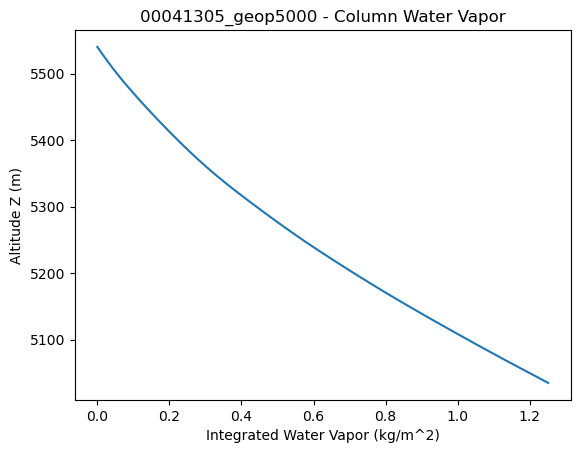

In [112]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from src.cosmo_lidar.atm_tools import vapor_pressure, pwv_profile
from src.cosmo_lidar.io import to_float64

# Constantes physiques
R_water = 461.5    # J/(kg·K)
epsilon = 0.622    # rapport des masses molaires Mv/Md

PROJECT_ROOT = Path("..").resolve()                     # <- remonte d'un cran
PARQUET_DIR  = PROJECT_ROOT / "data" / "processed-graph"  # ../data/processed-graph
PARQUET_DIR.mkdir(parents=True, exist_ok=True)

for path in sorted(data.keys()):
    cols = data[path]

    # ---------------------------
    # Colonnes physiques
    # ---------------------------
    TEMP = to_float64(cols["TEMP"]) + 273.15        # K
    Z    = to_float64(cols["GEOP"])                 # m ; déjà trié croissant (bas -> haut)
    TDEW = to_float64(cols["TDEW"]) + 273.15        # K

    RH   = to_float64(cols.get("RH"))  if "RH"  in cols else None   # %
    PMB  = to_float64(cols.get("PMB")) if "PMB" in cols else None   # hPa

    # ---------------------------
    # Vapeur d'eau
    # ---------------------------
    # Pression partielle de vapeur (hPa) à partir du point de rosée
    e_hPa = vapor_pressure(TDEW)  # ta fonction existante

    # Densité de vapeur d'eau rho_water (kg/m^3)
    rho_water = (e_hPa * 100.0) / (R_water * TEMP)

    # Rapport de mélange vapeur d'eau : WVMR (g/kg)
    # epsilon * e / (P - e) donne kg/kg ; *1000 -> g/kg
    if PMB is not None:
        WVMR = epsilon * e_hPa / (PMB - e_hPa) * 1000.0
    else:
        WVMR = None

    # ---------------------------
    # Profil PWV intégré
    # ---------------------------
    # Utilisation directe de TA fonction pwv_profile :
    # pwv_profile(rho_water, Z) renvoie :
    #  - valeur max au sol (PWV total colonne)
    #  - 0 en haut
    IWV_profile = pwv_profile(rho_water, Z)  # kg/m^2

    # ---------------------------
    # Dossier de sortie
    # ---------------------------
    stem = path.stem  # ex: "00060814_geop5000"
    outdir = PARQUET_DIR / f"{stem}_plots"
    os.makedirs(outdir, exist_ok=True)

    # ---------------------------
    # 1) Z en fonction de WVMR
    # ---------------------------
    if WVMR is not None:
        plt.figure()
        plt.plot(WVMR, Z)
        plt.xlabel("WVMR (g/kg)")
        plt.ylabel("Altitude Z (m)")
        plt.title(f"{stem} - WVMR profile")
        plt.savefig(outdir / f"{stem}_Z_vs_WVMR.png", dpi=300, bbox_inches="tight")
        plt.close()

    # ---------------------------
    # 2) Z en fonction de la Température
    # ---------------------------
    plt.figure()
    plt.plot(TEMP, Z)
    plt.xlabel("Temperature (K)")
    plt.ylabel("Altitude Z (m)")
    plt.title(f"{stem} - Temperature profile")
    plt.savefig(outdir / f"{stem}_Z_vs_Temp.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ---------------------------
    # 3) Z en fonction de la Pression
    # ---------------------------
    if PMB is not None:
        plt.figure()
        plt.plot(PMB, Z)
        plt.xlabel("Pressure (hPa)")
        plt.ylabel("Altitude Z (m)")
        plt.title(f"{stem} - Pressure profile")
        plt.savefig(outdir / f"{stem}_Z_vs_Pressure.png", dpi=300, bbox_inches="tight")
        plt.close()

    # ---------------------------
    # 4) Contenu intégré en vapeur d'eau vs altitude
    # ---------------------------
    # Remarque : IWV_profile est en kg/m^2,
    # et décroît avec l'altitude (PWV total en bas → 0 en haut).
    plt.figure()
    plt.plot(IWV_profile, Z)
    plt.xlabel("Integrated Water Vapor (kg/m^2)")
    plt.ylabel("Altitude Z (m)")
    plt.title(f"{stem} - Column Water Vapor")
    plt.savefig(outdir / f"{stem}_IWV_vs_Z.png", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Figures sauvées dans {outdir}")
    
    
#amelioration possible : ajuster la taille des légendes, des titres, etc., transformer le titre du nom du fichier avec la date exacte


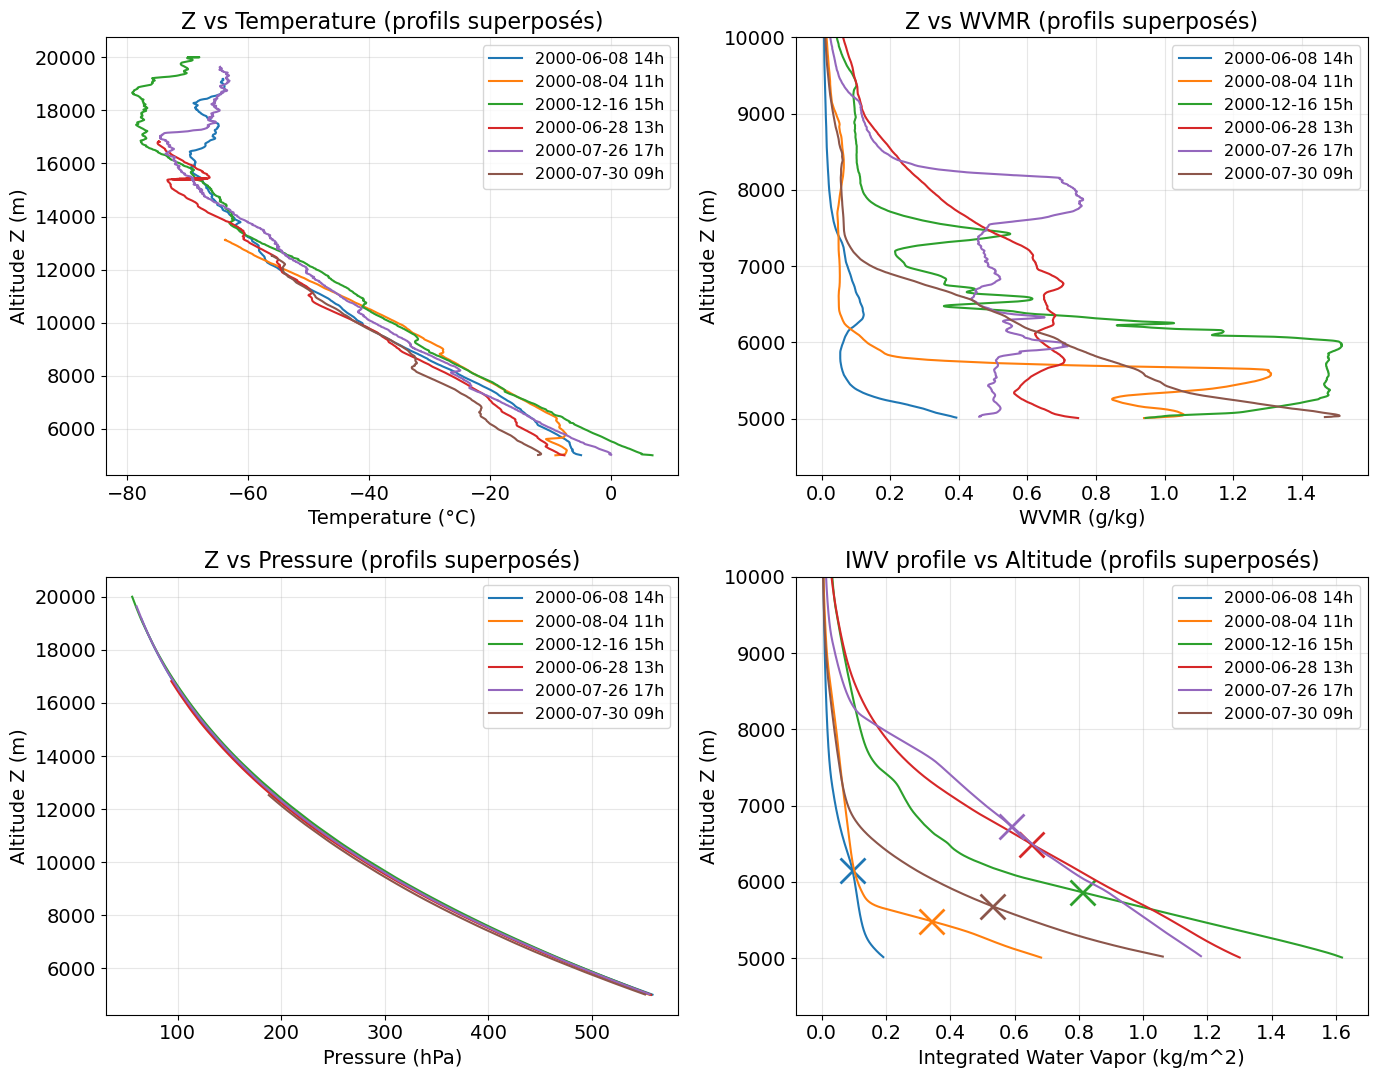

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

from src.cosmo_lidar.io import load_table, to_float64
from src.cosmo_lidar.atm_tools import vapor_pressure, pwv_profile

import matplotlib as mpl #pour choisir la taille des graphiques ?
mpl.rcParams['font.size'] = 14          # taille par défaut des labels/texte
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2.5

# --- paramètres ---
base_dir = Path("../data/processed")
files = [
    "00060814_geop5000.parquet",
    "00080411_geop5000.parquet",
    "00121615_geop5000.parquet",
    "00062813_geop5000.parquet",
    "00072617_geop5000.parquet",
    "00073009_geop5000.parquet",
]

R_water = 461.5
epsilon = 0.622

# parse label depuis stem YYMMDDHH -> YYYY-MM-DD HHh
def human_label_from_stem(stem: str) -> str:
    token = stem.split("_")[0]
    if len(token) >= 8 and token[:8].isdigit():
        yy = int(token[0:2]); mm = int(token[2:4]); dd = int(token[4:6]); hh = int(token[6:8])
        year = 2000 + yy if yy <= 50 else 1900 + yy
        return f"{year:04d}-{mm:02d}-{dd:02d} {hh:02d}h"
    return stem

# Prépare la figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
ax_temp, ax_wvmr, ax_pres, ax_iwv = axes.flat
cmap = plt.get_cmap("tab10")

for i, fname in enumerate(files):
    p = base_dir / fname
    if not p.exists():
        print(f"[WARN] fichier manquant: {p}")
        continue
    try:
        df = load_table(p)
    except Exception as e:
        print(f"[WARN] échec lecture {p.name}: {e}")
        continue

    # colonne altitude tolérante
    geop_col = None
    for c in df.columns:
        cu = str(c).upper()
        if cu.startswith("GEOP") or cu.startswith("GEOM"):
            geop_col = c
            break
    if geop_col is None:
        print(f"[WARN] pas de GEOP/GEOM dans {p.name}")
        continue

    Z = to_float64(df[geop_col])                        # m
    TEMP = to_float64(df.get("TEMP", df.get("Temp")))  # °C or already K in your data; adjust if needed
    # keep TEMP in K for calculations if needed: if values look like Celsius, add 273.15
    # here we detect typical range: if max < 80 assume °C -> convert to K
    TEMP_K = None
    if TEMP is not None:
        if np.nanmax(TEMP) < 80:
            TEMP_K = TEMP + 273.15
        else:
            TEMP_K = TEMP

    TDEW = to_float64(df.get("TDEW"))
    PMB = to_float64(df.get("PMB"))

    # calc vapeur d'eau si possible
    WVMR = None
    rho_water = None
    IWV = None
    if TDEW is not None and PMB is not None and TEMP_K is not None:
        e_hPa = vapor_pressure(TDEW + 273.15 if np.nanmax(TDEW) < 80 else TDEW)
        with np.errstate(invalid="ignore", divide="ignore"):
            WVMR = epsilon * e_hPa / (PMB - e_hPa) * 1000.0  # g/kg
            rho_water = (e_hPa * 100.0) / (R_water * TEMP_K)  # kg/m3
        try:
            IWV = pwv_profile(rho_water, Z)
        except Exception:
            IWV = None
    
        # calcul z50 (altitude du 50% d'eau intégrée) et valeur IWV correspondante
    
    z50 = calcul_z_percentile_wvc(Z, rho_water, 50)
    iwv_at_z50 = float(np.interp(z50, Z, IWV))
            

    # masque valide et tri
    mask = np.isfinite(Z)
    if WVMR is not None:
        mask &= np.isfinite(WVMR)
    if TEMP_K is not None:
        mask &= np.isfinite(TEMP_K)
    if PMB is not None:
        mask &= np.isfinite(PMB)
    if rho_water is not None:
        mask &= np.isfinite(rho_water)
    if np.count_nonzero(mask) < 2:
        print(f"[WARN] pas assez de points valides pour {p.name}")
        continue

    Zv = Z[mask]
    order = np.argsort(Zv)
    Zv = Zv[order]

    Wv = WVMR[mask][order] if WVMR is not None else None
    Tv = TEMP_K[mask][order] if TEMP_K is not None else None
    Pv = PMB[mask][order] if PMB is not None else None
    Iv = IWV[mask][order] if (IWV is not None and np.shape(IWV) == np.shape(Z)) else IWV

    label = human_label_from_stem(p.stem)
    color = cmap(i % cmap.N)

    if Wv is not None:
        ax_wvmr.plot(Wv, Zv, label=label, color=color, lw=1.5)
    if Tv is not None:
        ax_temp.plot(Tv - 273.15, Zv, label=label, color=color, lw=1.5)  # affiche en °C
    if Pv is not None:
        ax_pres.plot(Pv, Zv, label=label, color=color, lw=1.5)
    if Iv is not None:
        # si IWV est scalaire (PWV total), tracer point; si profil, tracer la courbe
        if np.ndim(Iv) == 0 or (np.ndim(Iv) == 1 and Iv.size == 1):
            ax_iwv.scatter(float(Iv), Zv[0], label=label, color=color)
        else:
            ax_iwv.plot(Iv, Zv, label=label, color=color, lw=1.5)
        ax_iwv.plot(iwv_at_z50, z50, marker='x', color=color, markersize=18, markeredgewidth=2)    

# mise en forme


ax_temp.set_xlabel("Temperature (°C)")
ax_temp.set_ylabel("Altitude Z (m)")

ax_temp.set_title("Z vs Temperature (profils superposés)")
ax_temp.grid(alpha=0.3); ax_temp.legend(fontsize="small")

ax_wvmr.set_xlabel("WVMR (g/kg)")
ax_wvmr.set_ylabel("Altitude Z (m)")
ax_wvmr.set_ylim(top=10000)
ax_wvmr.set_title("Z vs WVMR (profils superposés)")
ax_wvmr.grid(alpha=0.3); ax_wvmr.legend(fontsize="small")

ax_pres.set_xlabel("Pressure (hPa)")
ax_pres.set_ylabel("Altitude Z (m)")

ax_pres.set_title("Z vs Pressure (profils superposés)")
ax_pres.grid(alpha=0.3); ax_pres.legend(fontsize="small")

ax_iwv.set_xlabel("Integrated Water Vapor (kg/m^2)")
ax_iwv.set_ylabel("Altitude Z (m)")
ax_iwv.set_ylim(top=10000)
ax_iwv.set_title("IWV profile vs Altitude (profils superposés)")
ax_iwv.grid(alpha=0.3); ax_iwv.legend(fontsize="small")

plt.tight_layout()
plt.show()